In [1]:
import pandas as pd
import joblib

In [2]:
## loading the models
rf_model = joblib.load('../models/churn_rf_model.pkl')
pca = joblib.load('../models/pca.pkl')
scaler = joblib.load('../models/scaler.pkl')

#### creating the preprocessing pipeline created earlier

In [3]:
df = pd.read_csv('../data/phase3_feature_engineering.csv')

In [4]:
X = df.drop(columns=['churn'])
y = df['churn']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
cols_to_drop = X_train.select_dtypes(include='object').columns

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [7]:
X_test_scaled = scaler.transform(X_test)

In [8]:
X_test_pca = pca.transform(X_test_scaled)

In [9]:
## churn probability

y_prob = rf_model.predict_proba(X_test_pca)[:,1]

In [10]:
results_df = X_test.copy()

results_df['actual_churn'] = y_test
results_df['churn_probability'] = y_prob

In [11]:
## defining the risk segments

def risk_segment(prob):
    
    if prob >= 0.7:
        return "High Risk"
    
    elif prob >= 0.4:
        return "Medium Risk"
    
    else:
        return "Low Risk"


results_df['risk_segment'] = results_df['churn_probability'].apply(risk_segment)

In [12]:
results_df['risk_segment'].value_counts()

risk_segment
Low Risk       3514
Medium Risk    1517
High Risk       972
Name: count, dtype: int64

In [13]:
df['avg_rech_amt_6_7']

0        1185.0
1         519.0
2         380.0
3         459.0
4         408.0
          ...  
30006     392.0
30007     465.0
30008     848.5
30009     467.0
30010     369.5
Name: avg_rech_amt_6_7, Length: 30011, dtype: float64

In [14]:
## customer value segmentation

def customer_value(spend):

    if spend >= results_df['avg_rech_amt_6_7'].quantile(0.9):
        return "High Value"
    
    elif spend >= results_df['avg_rech_amt_6_7'].quantile(0.5):
        return "Medium Value"
    
    else:
        return "Low Value"


results_df['value_segment'] = results_df['avg_rech_amt_6_7'].apply(customer_value)

In [15]:
## combining the value and risk segment

results_df['customer_segment'] = results_df['value_segment'] + " - " + results_df['risk_segment']

In [16]:
results_df['customer_segment']

3560           Low Value - Low Risk
25643       Medium Value - Low Risk
25557       Medium Value - Low Risk
22024          Low Value - Low Risk
9596     Medium Value - Medium Risk
                    ...            
28706    Medium Value - Medium Risk
23011         Low Value - High Risk
17780         High Value - Low Risk
28350         Low Value - High Risk
5922           Low Value - Low Risk
Name: customer_segment, Length: 6003, dtype: object

In [17]:
## segment distribution
results_df['customer_segment'].value_counts()

customer_segment
Low Value - Low Risk          1649
Medium Value - Low Risk       1475
Low Value - Medium Risk        826
Medium Value - Medium Risk     549
Low Value - High Risk          523
High Value - Low Risk          390
Medium Value - High Risk       380
High Value - Medium Risk       142
High Value - High Risk          69
Name: count, dtype: int64

### here we take the strategic actions

#### map segments to action

In [18]:
def recommended_action(segment):

    if segment == "High Value - High Risk":
        return "Immediate personal intervention (retention call / loyalty discount)"
    
    elif segment == "Medium Value - High Risk":
        return "Automated SMS/email with discounted data pack"
    
    elif segment == "Low Value - High Risk":
        return "Minimal intervention"

    else:
        return "No action required"


results_df['recommended_action'] = results_df['customer_segment'].apply(recommended_action)

In [19]:
## glimpse of the strategy table

results_df[['customer_segment','recommended_action']].head(20)

,customer_segment,recommended_action
3560,Low Value - Low Risk,No action required
25643,Medium Value - Low Risk,No action required
25557,Medium Value - Low Risk,No action required
22024,Low Value - Low Risk,No action required
9596,Medium Value - Medium Risk,No action required
22141,Low Value - Low Risk,No action required
15368,Low Value - High Risk,Minimal intervention
25429,Medium Value - Medium Risk,No action required
2590,Medium Value - High Risk,Automated SMS/email with discounted data pack
14880,Medium Value - Medium Risk,No action required


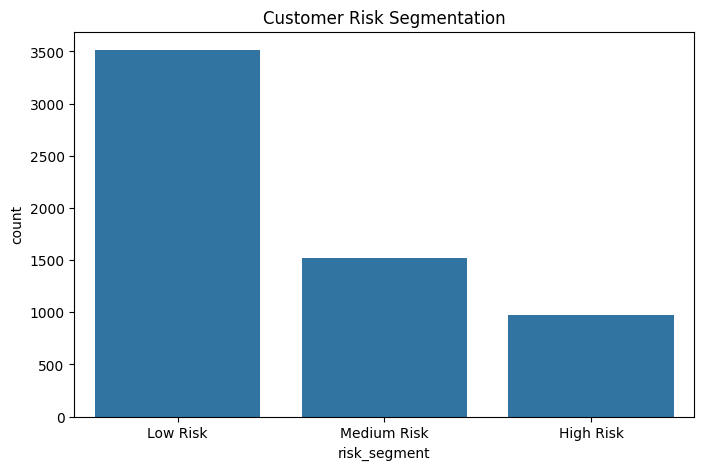

In [20]:
## visualization of the project

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=results_df,
    x='risk_segment',
    order=['Low Risk','Medium Risk','High Risk']
)

plt.title("Customer Risk Segmentation")
plt.show()

### 2. Feature importance visualization

In [21]:
## importing some files

log_model = joblib.load("../models/logistic_churn_model.pkl")
feature_names = joblib.load("../models/feature_names.pkl")

In [22]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_model.coef_[0]
})

In [23]:
feature_importance["Importance"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

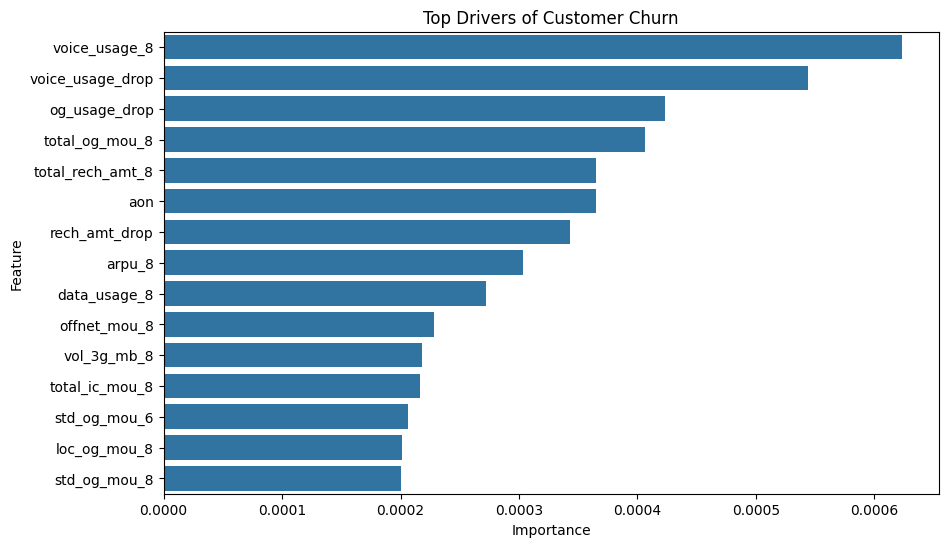

In [24]:
## visualization
import seaborn as sns
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top Drivers of Customer Churn")

plt.show()

In [25]:
results_df

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,...,voice_usage_8,voice_avg_6_7,voice_usage_drop,data_voice_ratio_8,actual_churn,churn_probability,risk_segment,value_segment,customer_segment,recommended_action
3560,7001368948,109,0.0,0.0,0.0,261.154,455.428,741.622,72.31,18.71,...,604.87,641.630,-36.760,0.000000,0,0.073437,Low Risk,Low Value,Low Value - Low Risk,No action required
25643,7000520443,109,0.0,0.0,0.0,905.169,708.586,640.842,47.56,85.26,...,951.72,1117.115,-165.395,0.795806,0,0.152231,Low Risk,Medium Value,Medium Value - Low Risk,No action required
25557,7001808508,109,0.0,0.0,0.0,735.260,586.475,671.356,4.73,4.29,...,1634.42,1409.305,225.115,0.000000,0,0.235302,Low Risk,Medium Value,Medium Value - Low Risk,No action required
22024,7001517339,109,0.0,0.0,0.0,428.944,430.112,528.402,170.43,69.43,...,1413.02,1164.560,248.460,0.000000,0,0.323586,Low Risk,Low Value,Low Value - Low Risk,No action required
9596,7000792852,109,0.0,0.0,0.0,417.224,712.078,436.000,24.63,5.28,...,311.99,305.760,6.230,1.493530,0,0.477849,Medium Risk,Medium Value,Medium Value - Medium Risk,No action required
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28706,7001816899,109,0.0,0.0,0.0,531.320,677.381,662.619,101.18,89.73,...,524.95,814.665,-289.715,2.497994,0,0.408648,Medium Risk,Medium Value,Medium Value - Medium Risk,No action required
23011,7002266419,109,0.0,0.0,0.0,524.869,222.999,71.561,205.01,96.01,...,91.67,658.600,-566.930,0.000000,1,0.932097,High Risk,Low Value,Low Value - High Risk,Minimal intervention
17780,7000102177,109,0.0,0.0,0.0,1406.705,1603.157,1719.877,609.44,670.16,...,2336.54,2774.230,-437.690,0.000000,0,0.166565,Low Risk,High Value,High Value - Low Risk,No action required
28350,7000357552,109,0.0,0.0,0.0,739.750,40.470,0.000,588.64,15.21,...,0.00,691.145,-691.145,0.000000,0,0.957883,High Risk,Low Value,Low Value - High Risk,Minimal intervention


In [26]:
joblib.dump(results_df, '../models/results_df.pkl')

['../models/results_df.pkl']